In [1]:
import pandas as pd
import numpy as np
from joblib import load
from preprocessor import *
from Preprocessor_LLM import *
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from transformers import pipeline
#import torch
import re
import sys
import os
from openai import OpenAI


PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# PROMPT A MODIFIER ICI


PROMPT_CONFIG = {
    # ========== STRATÉGIE GLOBALE ==========
    "objectif": "Sélectionner les cas les plus utiles pour améliorer la détection de fraude",
    
    # ========== CE QUE LE LLM DOIT PRIVILÉGIER ==========
    "priorites": [
        "Chercher des profils très différents les uns des autres",
        "Inclure des cas suspects avec des combinaisons inhabituelles",
        "Couvrir tout le spectre de probabilités (pas seulement le milieu)",
        "Ajouter quelques cas extrêmes et atypiques"
    ],
    
    # ========== CE QUE LE LLM DOIT ÉVITER ==========
    "a_eviter": [
        "Sélectionner 50 profils similaires",
        "Se concentrer uniquement sur les cas moyens",
        "Ignorer les cas rares ou extrêmes"
    ],
    
    # ========== EXEMPLES DE PATTERNS À DÉTECTER ==========
    "patterns_interessants": [
        "Jeune conducteur + véhicule cher",
        "Pas de témoin + pas de rapport police",
        "Délai très court ou très long avant déclaration",
        "Changement d'adresse récent"
    ],
    
    # ========== PARAMÈTRES NUMÉRIQUES ==========
    "n_preselect": 200,  # Combien présélectionner par uncertainty sampling
    "n_select": 50,      # Combien sélectionner au final
}

print("✓ Configuration stratégie LLM chargée")
print(f"  Objectif: {PROMPT_CONFIG['objectif']}")
print(f"  {len(PROMPT_CONFIG['priorites'])} priorités définies")
print(f"  Présélection: {PROMPT_CONFIG['n_preselect']} → Sélection: {PROMPT_CONFIG['n_select']}")

✓ Configuration stratégie LLM chargée
  Objectif: Sélectionner les cas les plus utiles pour améliorer la détection de fraude
  4 priorités définies
  Présélection: 200 → Sélection: 50


In [3]:
data = pd.read_csv('/home/onyxia/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv')

X = data.drop(columns=['FraudFound_P'])
y = data['FraudFound_P']

print(X.head())
print(y.head())


   Unnamed: 0    Make AccidentArea     Sex MaritalStatus  Age          Fault  \
0           0   Honda        Urban  Female        Single   21  Policy Holder   
1           1   Honda        Urban    Male        Single   34  Policy Holder   
2           2   Honda        Urban    Male       Married   47  Policy Holder   
3           3  Toyota        Rural    Male       Married   65    Third Party   
4           4   Honda        Urban  Female        Single   27    Third Party   

          PolicyType     VehiclePrice  Deductible  ...  Days_Policy_Accident  \
0  Sport - Liability  more than 69000         300  ...          more than 30   
1  Sport - Collision  more than 69000         400  ...          more than 30   
2  Sport - Collision  more than 69000         400  ...          more than 30   
3  Sedan - Liability   20000 to 29000         400  ...          more than 30   
4  Sport - Collision  more than 69000         400  ...          more than 30   

  PastNumberOfClaims AgeOfVehicle Poli

In [4]:
preprocessor = load("preprocessor.joblib")
print("✓ Preprocessor numérique chargé")

preprocessor_llm = PreprocessLLM(
    label_cols=label_cols,
    freq_cols=freq_cols,
    ordinal_cols=ordinal_cols,
    binary_cols=binary_cols,
    scale_cols=scale_cols
)

all_cols = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols
X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_cols)

X_raw = X.copy()

print(f"  Données numériques: {X_preprocessed.shape}")
print(f"  Données brutes (pour LLM): {X_raw.shape}")

exemple_text = preprocessor_llm.transform(X_raw.head(1))
print("\n Exemple preprocessing LLM:")
print(exemple_text[0]['text'])

✓ Preprocessor numérique chargé
  Données numériques: (15419, 20)
  Données brutes (pour LLM): (15419, 21)

 Exemple preprocessing LLM:
Âge : 21 ans
Délai avant déclaration : 1 semaines
Sexe : Female
Zone de l'accident : Urban
Responsabilité : Policy Holder
Rapport de police : No
Présence de témoins : No
Type d'agent : External
VehiclePrice : more than 69000
Days_Policy_Accident : more than 30
PastNumberOfClaims : none
AgeOfVehicle : 3 years
NumberOfSuppliments : none
AddressChange_Claim : 1 year
NumberOfCars : 3 to 4
DriverRating : 1
Deductible : 300
PolicyType : Sport - Liability
Make : Honda
MaritalStatus : Single


Le preprocessor LLM sert à convertir en données textuelles les individus, de sorte que le LLM traite la base de données choisie.

In [5]:
# Split des données

# 20% pour le test
X_pool_full, X_test, y_pool_full, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, stratify=y, random_state=42
)

# De même pour les raw
X_raw_pool_full, X_raw_test, _, _ = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# 2% d'observations initiales pour le seed
X_init, X_pool, y_init, y_pool = train_test_split(
    X_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
)

# De même pour les raw
X_raw_init, X_raw_pool, _, _ = train_test_split(
    X_raw_pool_full, y_pool_full, train_size=0.02, stratify=y_pool_full, random_state=42
)

# Données pour uncertainty sampling
X_init_US = X_init.copy()
X_pool_US = X_pool.copy()
y_init_US = y_init.copy()
y_pool_US = y_pool.copy()

# Données pour LLM sampling
X_init_LLM = X_init.copy()
X_pool_LLM = X_pool.copy()
X_raw_pool_LLM = X_raw_pool.copy()
y_init_LLM = y_init.copy()
y_pool_LLM = y_pool.copy()

print(f"  Test set: {len(X_test)} observations")
print(f"  Pool initial: {len(X_pool)} observations")
print(f"  Seed initial: {len(X_init)} observations ({len(X_init)/len(X_pool_full)*100:.1f}%)")

  Test set: 3084 observations
  Pool initial: 12089 observations
  Seed initial: 246 observations (2.0%)


In [6]:
# CELLULE DE TEST
print("Test des imports:")

try:
    import torch
    print(f"✓ torch {torch.__version__}")
except Exception as e:
    print(f"❌ torch: {e}")

try:
    import transformers
    print(f"✓ transformers {transformers.__version__}")
except Exception as e:
    print(f"❌ transformers: {e}")

try:
    from transformers import pipeline
    print(f"✓ pipeline importable")
except Exception as e:
    print(f"❌ pipeline: {e}")

# Test simple
try:
    from transformers import pipeline
    test_pipeline = pipeline("text-generation", model="gpt2", max_new_tokens=10)
    result = test_pipeline("Hello", max_length=5)
    print(f"✓ Pipeline fonctionnel")
    print(f"  Résultat test: {result}")
except Exception as e:
    print(f"❌ Pipeline test: {e}")
    import traceback
    traceback.print_exc()

Test des imports:
❌ torch: No module named 'torch'
✓ transformers 5.2.0
✓ pipeline importable


❌ Pipeline test: name 'torch' is not defined


Traceback (most recent call last):
  File "/tmp/ipykernel_36656/3167838744.py", line 25, in <module>
    test_pipeline = pipeline("text-generation", model="gpt2", max_new_tokens=10)
  File "/home/onyxia/PROJET_STATAPP/.venv/lib/python3.13/site-packages/transformers/pipelines/__init__.py", line 827, in pipeline
    if isinstance(dtype, str) and hasattr(torch, dtype):
                                          ^^^^^
NameError: name 'torch' is not defined


In [7]:
# Initialisation des modèles et du SMOTE (par rapport à l'AL, ajout du model_LLM)

model = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

model_US = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

model_LLM = LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    n_estimators=300,
    random_state=42
)

# SMOTE
smote = SMOTE(sampling_strategy=0.25, random_state=42)

Ici, la partie fallback est utile dans le cas où torch rencontre un problème : il peut arriver que le module soit importé mais que vscode ne le reconnaisse pas, dans ce cas on fait usage du pseudo-LLM dans le modèle. 

In [8]:
# ===========================
# INITIALISATION DU SÉLECTEUR LLM
# ===========================
print("\n" + "="*60)
print("INITIALISATION DU SÉLECTEUR LLM")
print("="*60)

class LLMSimplifiedSelector:
    """
    Sélecteur LLM piloté par des instructions en français simple.
    Traduit automatiquement les priorités en stratégie algorithmique.
    """
    
    def __init__(self, config):
        self.config = config
        self.n_select = config["n_select"]
        
        # Interpréter les priorités pour définir les poids
        self.weights = self._interpret_priorities(config["priorites"])
        
        print(f"\n📋 Interprétation de la stratégie:")
        print(f"   Objectif: {config['objectif']}")
        print(f"   Priorités détectées:")
        for key, value in self.weights.items():
            if value > 0:
                print(f"     - {key}: {value*100:.0f}%")
    
    def _interpret_priorities(self, priorites):
        """
        Analyse les phrases de priorité et détermine les poids automatiquement.
        """
        weights = {
            "diversite_proba": 0.0,
            "extremes": 0.0,
            "diversite_features": 0.0,
            "aleatoire": 0.0
        }
        
        priorities_text = " ".join(priorites).lower()
        
        # Détection de mots-clés pour ajuster les poids
        keywords = {
            "diversite_proba": ["spectre", "probabilités", "tout le spectre", "couvrir", "toutes les probabilités"],
            "extremes": ["extrêmes", "très haut", "très bas", "red flags", "évidentes", "clairs"],
            "diversite_features": ["différents", "profils variés", "diversité", "varier", "types"],
            "aleatoire": ["hasard", "aléatoire", "exploration", "tout", "sans biais"]
        }
        
        scores = {k: 0 for k in weights.keys()}
        
        for strategy, words in keywords.items():
            for word in words:
                if word in priorities_text:
                    scores[strategy] += 1
        
        total_score = sum(scores.values())
        
        if total_score > 0:
            # Normaliser pour obtenir des poids qui somment à 1
            for key in weights.keys():
                weights[key] = scores[key] / total_score
        else:
            # Configuration par défaut si aucun mot-clé détecté
            weights = {
                "diversite_proba": 0.20,
                "extremes": 0.15,
                "diversite_features": 0.40,
                "aleatoire": 0.25
            }
        
        # Ajuster selon certaines phrases spécifiques
        if "cas moyens" in priorities_text or "ambigus" in priorities_text:
            # Réduire les extrêmes
            weights["extremes"] *= 0.5
            # Redistribuer aux autres
            total = sum(weights.values())
            for k in weights.keys():
                weights[k] /= total
        
        if "exploration" in priorities_text or "hasard" in priorities_text:
            # Augmenter l'aléatoire
            weights["aleatoire"] = max(0.4, weights["aleatoire"])
            # Renormaliser
            total = sum(weights.values())
            for k in weights.keys():
                weights[k] /= total
        
        return weights
    
    def select(self, X_raw_preselect, preselect_proba, n_select=None):
        """Sélectionne les meilleurs échantillons selon la config"""
        import random
        
        if n_select is None:
            n_select = self.n_select
        
        n_total = len(X_raw_preselect)
        n_select = min(n_select, n_total)
        selected = []
        
        # Calculer combien pour chaque stratégie
        n_diverse_proba = max(1, int(n_select * self.weights["diversite_proba"]))
        n_extreme = max(1, int(n_select * self.weights["extremes"]))
        n_feature_diverse = max(1, int(n_select * self.weights["diversite_features"]))
        n_random = n_select - n_diverse_proba - n_extreme - n_feature_diverse
        
        print(f"    Distribution automatique:")
        print(f"      Diversité probabilités: {n_diverse_proba}")
        print(f"      Cas extrêmes: {n_extreme}")
        print(f"      Diversité features: {n_feature_diverse}")
        print(f"      Aléatoire: {n_random}")
        
        # ========== STRATÉGIE 1: Diversité par probabilité ==========
        if n_diverse_proba > 0:
            proba_bins = np.linspace(0, 1, n_diverse_proba + 1)
            for i in range(len(proba_bins) - 1):
                bin_mask = (preselect_proba >= proba_bins[i]) & (preselect_proba < proba_bins[i+1])
                bin_indices = np.where(bin_mask)[0]
                if len(bin_indices) > 0:
                    selected.append(int(np.random.choice(bin_indices)))
        
        # ========== STRATÉGIE 2: Cas extrêmes ==========
        if n_extreme > 0:
            remaining_idx = [i for i in range(n_total) if i not in selected]
            if remaining_idx:
                remaining_proba = preselect_proba[remaining_idx]
                # Top frauduleux
                n_fraud = n_extreme // 2
                top_fraud = np.argsort(remaining_proba)[-n_fraud:]
                selected.extend([remaining_idx[i] for i in top_fraud])
                # Top légitimes
                remaining_idx2 = [i for i in remaining_idx if i not in selected]
                if remaining_idx2:
                    remaining_proba2 = preselect_proba[remaining_idx2]
                    n_legit = n_extreme - n_fraud
                    top_legit = np.argsort(remaining_proba2)[:n_legit]
                    selected.extend([remaining_idx2[i] for i in top_legit])
        
        # ========== STRATÉGIE 3: Diversité des features ==========
        if n_feature_diverse > 0:
            remaining_idx = [i for i in range(n_total) if i not in selected]
            if remaining_idx:
                X_remaining = X_raw_preselect.iloc[remaining_idx]
                numeric_cols = X_remaining.select_dtypes(include=[np.number]).columns
                
                if len(numeric_cols) > 0:
                    X_numeric = X_remaining[numeric_cols].fillna(0).values
                    
                    # Normalisation
                    col_min = X_numeric.min(axis=0)
                    col_max = X_numeric.max(axis=0)
                    col_range = col_max - col_min
                    col_range[col_range == 0] = 1
                    X_normalized = (X_numeric - col_min) / col_range
                    
                    # Sélection greedy
                    diverse_local = []
                    centroid = X_normalized.mean(axis=0)
                    distances = np.linalg.norm(X_normalized - centroid, axis=1)
                    diverse_local.append(int(np.argmax(distances)))
                    
                    for _ in range(min(n_feature_diverse - 1, len(remaining_idx) - 1)):
                        already = X_normalized[diverse_local]
                        min_distances = np.full(len(remaining_idx), np.inf)
                        for sel_point in already:
                            dists = np.linalg.norm(X_normalized - sel_point, axis=1)
                            min_distances = np.minimum(min_distances, dists)
                        for idx in diverse_local:
                            min_distances[idx] = -np.inf
                        next_point = int(np.argmax(min_distances))
                        if next_point not in diverse_local:
                            diverse_local.append(next_point)
                    
                    selected.extend([remaining_idx[i] for i in diverse_local if remaining_idx[i] not in selected])
        
        # ========== STRATÉGIE 4: Aléatoire ==========
        if n_random > 0:
            remaining_idx = [i for i in range(n_total) if i not in selected]
            if remaining_idx:
                random_selected = random.sample(remaining_idx, min(n_random, len(remaining_idx)))
                selected.extend(random_selected)
        
        # Finalisation
        selected = list(set(selected))
        selected = [int(i) for i in selected if 0 <= i < n_total]
        
        # Compléter si nécessaire
        if len(selected) < n_select:
            remaining = [i for i in range(n_total) if i not in selected]
            random.shuffle(remaining)
            selected.extend(remaining[:n_select - len(selected)])
        
        return selected[:n_select]

# Instanciation
llm_selector = LLMSimplifiedSelector(config=PROMPT_CONFIG)

print(f"\n✓ Sélecteur LLM simplifié initialisé")
print("="*60)


INITIALISATION DU SÉLECTEUR LLM

📋 Interprétation de la stratégie:
   Objectif: Sélectionner les cas les plus utiles pour améliorer la détection de fraude
   Priorités détectées:
     - diversite_proba: 57%
     - extremes: 14%
     - diversite_features: 14%
     - aleatoire: 14%

✓ Sélecteur LLM simplifié initialisé


In [9]:
# ===========================
# FONCTIONS UTILITAIRES
# ===========================
def create_summary_for_llm(text_samples, n_examples=3):
    """Crée un résumé lisible des échantillons pour le LLM"""
    summary = f"Vous avez {len(text_samples)} échantillons présélectionnés.\n\n"
    summary += f"Exemples de {min(n_examples, len(text_samples))} premiers échantillons:\n\n"
    for i, sample in enumerate(text_samples[:n_examples]):
        summary += f"--- Échantillon {i} ---\n{sample['text']}\n\n"
    return summary

def create_llm_prompt(text_samples, n_select=50):
    """Crée le prompt pour le LLM"""
    summary = create_summary_for_llm(text_samples)
    
    prompt = f"""Tu es un expert en apprentissage actif pour la détection de fraude à l'assurance.
Tu dois sélectionner les {n_select} échantillons les plus informatifs parmi {len(text_samples)} candidats présélectionnés.

Critères de sélection:
1. Maximiser l'incertitude (cas ambigus, proches de la frontière de décision)
2. Assurer la diversité des profils (âges, types de véhicules, circonstances variées)
3. Prioriser les patterns inhabituels qui pourraient révéler des fraudes

{summary}

Basé sur ces principes, fournis UNIQUEMENT une liste Python des {n_select} indices (de 0 à {len(text_samples)-1}) les plus pertinents à labelliser.

Format attendu: [0, 5, 12, 18, 23, ...]

Indices sélectionnés:"""
    
    return prompt

def parse_llm_response(llm_output, n_max, fallback_n=50):
    """Parse la réponse du LLM pour extraire les indices"""
    try:
        match = re.search(r'\[[\d,\s]+\]', llm_output)
        if match:
            indices = eval(match.group())
            indices = [int(i) for i in indices if isinstance(i, (int, float)) and 0 <= int(i) < n_max]
            indices = indices[:fallback_n]
            
            if len(indices) < fallback_n:
                remaining = [i for i in range(n_max) if i not in indices]
                np.random.shuffle(remaining)
                indices.extend(remaining[:fallback_n - len(indices)])
            
            print(f"  ✓ {len(indices)} indices extraits")
            return indices
        else:
            print("  ⚠ Aucune liste trouvée, fallback")
            return list(range(min(fallback_n, n_max)))
    except Exception as e:
        print(f"  ⚠ Erreur parsing: {e}")
        return list(range(min(fallback_n, n_max)))

print("✓ Fonctions utilitaires définies")

✓ Fonctions utilitaires définies


In [10]:
token = os.environ["HF_TOKEN"]

In [11]:
client = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

In [ ]:
# ===========================
# BOUCLE D'ACTIVE LEARNING
# ===========================
results = []
iteration = 0

print("\n" + "="*60)
print("DÉBUT DE LA BOUCLE D'ACTIVE LEARNING")
print("="*60)

while len(X_init) < 3000 and len(X_pool) > 0:
    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration} - Labels: {len(X_init)}")
    print(f"{'='*60}")
    
    # ========== RESET DES INDEX (CRUCIAL) ==========
    X_pool = X_pool.reset_index(drop=True)
    y_pool = y_pool.reset_index(drop=True)
    X_pool_US = X_pool_US.reset_index(drop=True)
    y_pool_US = y_pool_US.reset_index(drop=True)
    X_pool_LLM = X_pool_LLM.reset_index(drop=True)
    X_raw_pool_LLM = X_raw_pool_LLM.reset_index(drop=True)
    y_pool_LLM = y_pool_LLM.reset_index(drop=True)
    
    # ---- SMOTE ----
    X_init_smote, y_init_smote = smote.fit_resample(X_init, y_init)
    X_init_US_smote, y_init_US_smote = smote.fit_resample(X_init_US, y_init_US)
    X_init_LLM_smote, y_init_LLM_smote = smote.fit_resample(X_init_LLM, y_init_LLM)
    
    # ---- Entraînement ----
    model.fit(X_init_smote, y_init_smote)
    model_US.fit(X_init_US_smote, y_init_US_smote)
    model_LLM.fit(X_init_LLM_smote, y_init_LLM_smote)
    
    # ---- Évaluation ----
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    y_test_US_pred = model_US.predict(X_test)
    y_test_US_proba = model_US.predict_proba(X_test)[:, 1]
    
    y_test_LLM_pred = model_LLM.predict(X_test)
    y_test_LLM_proba = model_LLM.predict_proba(X_test)[:, 1]
    
    # Stockage
    results.append({
        "labels_used": len(X_init),
        "accuracy_random_sampling": accuracy_score(y_test, y_test_pred),
        "f1_random_sampling": f1_score(y_test, y_test_pred),
        "recall_random_sampling": recall_score(y_test, y_test_pred),
        "precision_random_sampling": precision_score(y_test, y_test_pred),
        "auc_random_sampling": roc_auc_score(y_test, y_test_proba),
        "accuracy_uncertainty_sampling": accuracy_score(y_test, y_test_US_pred),
        "f1_uncertainty_sampling": f1_score(y_test, y_test_US_pred),
        "recall_uncertainty_sampling": recall_score(y_test, y_test_US_pred),
        "precision_uncertainty_sampling": precision_score(y_test, y_test_US_pred),
        "auc_uncertainty_sampling": roc_auc_score(y_test, y_test_US_proba),
        "accuracy_llm_sampling": accuracy_score(y_test, y_test_LLM_pred),
        "f1_llm_sampling": f1_score(y_test, y_test_LLM_pred),
        "recall_llm_sampling": recall_score(y_test, y_test_LLM_pred),
        "precision_llm_sampling": precision_score(y_test, y_test_LLM_pred),
        "auc_llm_sampling": roc_auc_score(y_test, y_test_LLM_proba)
    })
    
    print(f"AUC - Random: {results[-1]['auc_random_sampling']:.4f} | "
          f"US: {results[-1]['auc_uncertainty_sampling']:.4f} | "
          f"LLM: {results[-1]['auc_llm_sampling']:.4f}")
    
    # ---- Prédictions sur pools ----
    y_pool_proba = model.predict_proba(X_pool)[:, 1]
    y_pool_US_proba = model_US.predict_proba(X_pool_US)[:, 1]
    y_pool_LLM_proba = model_LLM.predict_proba(X_pool_LLM)[:, 1]
    
    # ========== RANDOM SAMPLING ==========
    print("\n[Random Sampling]")
    if len(X_pool) >= 50:
        x_batch, X_pool_new, y_batch, y_pool_new = train_test_split(
            X_pool, y_pool, train_size=50, stratify=y_pool, random_state=42
        )
        X_init = pd.concat([X_init, x_batch], ignore_index=True)
        y_init = pd.concat([y_init, y_batch], ignore_index=True)
        X_pool = X_pool_new
        y_pool = y_pool_new
        print(f"  +50 échantillons")
    else:
        print(f"  Pool épuisé")
        break
    
    # ========== UNCERTAINTY SAMPLING ==========
    print("\n[Uncertainty Sampling]")
    if len(X_pool_US) > 0:
        y_init_US_proba = model_US.predict_proba(X_init_US)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_init_US, y_init_US_proba)
        youden = tpr - fpr
        best_idx = np.argmax(youden)
        youden_threshold = thresholds[best_idx]
        
        dist_to_threshold = np.abs(y_pool_US_proba - youden_threshold)
        n_select = min(50, len(X_pool_US))
        query_idx = np.argsort(dist_to_threshold)[:n_select]
        
        X_new_US = X_pool_US.iloc[query_idx]
        y_new_US = y_pool_US.iloc[query_idx]
        X_init_US = pd.concat([X_init_US, X_new_US], ignore_index=True)
        y_init_US = pd.concat([y_init_US, y_new_US], ignore_index=True)
        
        # Suppression par masque
        mask = np.ones(len(X_pool_US), dtype=bool)
        mask[query_idx] = False
        X_pool_US = X_pool_US[mask].reset_index(drop=True)
        y_pool_US = y_pool_US[mask].reset_index(drop=True)
        
        print(f"  +{len(query_idx)} échantillons (seuil: {youden_threshold:.4f})")
    
    # ========== LLM SAMPLING ==========
    print("\n[LLM-based Sampling]")
    
    if len(X_pool_LLM) == 0:
        print("Pool épuisé")
        continue
    
    try:
        # Paramètres issus de PROMPT_CONFIG
        n_preselect = min(PROMPT_CONFIG["n_preselect"], len(X_pool_LLM))
        n_final_select = min(PROMPT_CONFIG["n_select"], n_preselect)
        
        # STEP 1 : Présélection par uncertainty sampling
        print(f"  Présélection: {n_preselect} candidats (US)")
        preselect_idx = np.random.choice(len(X_pool_LLM), size=n_preselect, replace=False)

        X_raw_preselect = X_raw_pool_LLM.iloc[preselect_idx].reset_index(drop=True)
        preselect_proba = y_pool_LLM_proba[preselect_idx]
        
        # STEP 2 : Sélection intelligente
        print(f"  Sélection intelligente de {n_final_select} parmi {n_preselect}...")
        text_samples = preprocessor_llm.transform(X_raw_preselect)
        prompt = create_llm_prompt(text_samples, n_select=n_final_select)

        completion = client.chat.completions.create(
            model="meta-llama/Llama-3.1-8B-Instruct",
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
        )

        selected_indices_in_preselect = parse_llm_response(completion.choices[0].message, n_preselect)
        
        # Validation
        selected_indices_in_preselect = [
            int(idx) for idx in selected_indices_in_preselect
            if 0 <= int(idx) < n_preselect
        ]
        print(f"  ✓ {len(selected_indices_in_preselect)} indices valides")
        
        # STEP 3 : Conversion en indices pool
        final_query_idx = preselect_idx[selected_indices_in_preselect]
        
        # STEP 4 : Mise à jour
        X_new_LLM = X_pool_LLM.iloc[final_query_idx]
        y_new_LLM = y_pool_LLM.iloc[final_query_idx]
        X_init_LLM = pd.concat([X_init_LLM, X_new_LLM], ignore_index=True)
        y_init_LLM = pd.concat([y_init_LLM, y_new_LLM], ignore_index=True)
        
        mask = np.ones(len(X_pool_LLM), dtype=bool)
        mask[final_query_idx] = False
        X_pool_LLM = X_pool_LLM[mask].reset_index(drop=True)
        X_raw_pool_LLM = X_raw_pool_LLM[mask].reset_index(drop=True)
        y_pool_LLM = y_pool_LLM[mask].reset_index(drop=True)
        
        print(f"  +{len(final_query_idx)} échantillons | Pool restant: {len(X_pool_LLM)}")
        
    except Exception as e:
        print(f"  ❌ ERREUR LLM: {e}")
        import traceback
        traceback.print_exc()


DÉBUT DE LA BOUCLE D'ACTIVE LEARNING

ITERATION 1 - Labels: 246
[LightGBM] [Info] Number of positive: 57, number of negative: 231
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 288, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197917 -> initscore=-1.399366
[LightGBM] [Info] Start training from score -1.399366
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [ ]:
# ===========================
# RÉSULTATS
# ===========================
results_df = pd.DataFrame(results)

print("\n Résultats finaux:")
print(results_df.tail(10))

# Sauvegarder
results_df.to_csv('active_learning_results.csv', index=False)
print("\n Résultats sauvegardés: active_learning_results.csv")

# Afficher
display(results_df.tail())


 Résultats finaux:
   labels_used  accuracy_random_sampling  f1_random_sampling  \
0          246                  0.922827            0.084615   
1          296                  0.924449            0.114068   
2          346                  0.921530            0.129496   
3          396                  0.926070            0.095238   
4          446                  0.925097            0.101167   
5          496                  0.924125            0.100000   

   recall_random_sampling  precision_random_sampling  auc_random_sampling  \
0                0.059459                   0.146667             0.634654   
1                0.081081                   0.192308             0.666624   
2                0.097297                   0.193548             0.678644   
3                0.064865                   0.179104             0.673787   
4                0.070270                   0.180556             0.691897   
5                0.070270                   0.173333             0.68

,labels_used,accuracy_random_sampling,f1_random_sampling,recall_random_sampling,precision_random_sampling,auc_random_sampling,accuracy_uncertainty_sampling,f1_uncertainty_sampling,recall_uncertainty_sampling,precision_uncertainty_sampling,auc_uncertainty_sampling,accuracy_llm_sampling,f1_llm_sampling,recall_llm_sampling,precision_llm_sampling,auc_llm_sampling
1,296,0.924449,0.114068,0.081081,0.192308,0.666624,0.933852,0.028571,0.016216,0.120000,0.575157,0.928664,0.120000,0.081081,0.230769,0.675629
2,346,0.921530,0.129496,0.097297,0.193548,0.678644,0.938067,0.030457,0.016216,0.250000,0.635796,0.922179,0.090909,0.064865,0.151899,0.685383
3,396,0.926070,0.095238,0.064865,0.179104,0.673787,0.937419,0.010256,0.005405,0.100000,0.621516,0.923152,0.091954,0.064865,0.157895,0.695539
4,446,0.925097,0.101167,0.070270,0.180556,0.691897,0.938392,0.020619,0.010811,0.222222,0.660308,0.925422,0.128788,0.091892,0.215190,0.710541
5,496,0.924125,0.100000,0.070270,0.173333,0.688690,0.939040,0.020833,0.010811,0.285714,0.719137,0.926070,0.149254,0.108108,0.240964,0.737947


✓ Graphique sauvegardé: active_learning_results.png


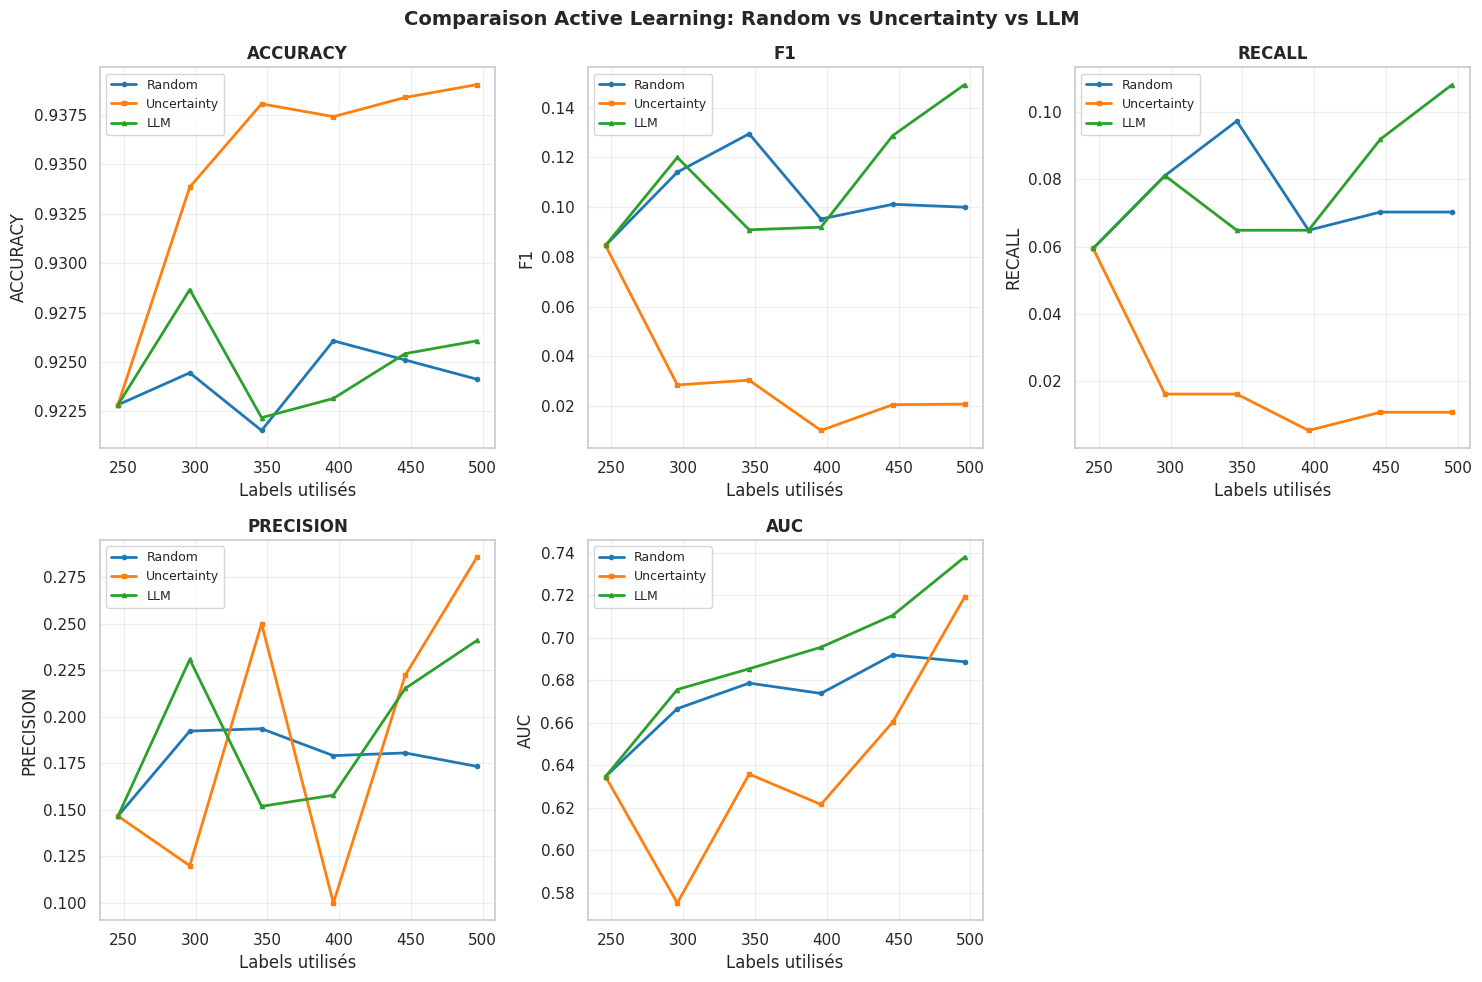

In [ ]:
# ===========================
# VISUALISATION
# ===========================
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
metrics = ["accuracy", "f1", "recall", "precision", "auc"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_random_sampling"], 
            'o-', label="Random", color=colors[0], linewidth=2, markersize=3)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_uncertainty_sampling"], 
            's-', label="Uncertainty", color=colors[1], linewidth=2, markersize=3)
    
    ax.plot(results_df["labels_used"], results_df[f"{metric}_llm_sampling"], 
            '^-', label="LLM", color=colors[2], linewidth=2, markersize=3)
    
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel("Labels utilisés")
    ax.set_ylabel(metric.upper())
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])

plt.suptitle("Comparaison Active Learning: Random vs Uncertainty vs LLM", 
             fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('active_learning_results.png', dpi=150, bbox_inches='tight')
print("✓ Graphique sauvegardé: active_learning_results.png")
plt.show()